In [1]:
import json
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
DATA_DIR = Path("../data")
def build_dataset_mapping():
    """
    Build mapping from UUID to dataset name by scanning data directory.
    
    Returns:
        dict: {uuid: dataset_name}
    """
    mapping = {}
    
    for uuid_dir in DATA_DIR.iterdir():
        if not uuid_dir.is_dir():
            continue
        
        uuid = uuid_dir.name
        
        # Find the first .xes or .csv file
        for file in uuid_dir.iterdir():
            if file.suffix in ['.xes', '.csv']:
                # Use filename without extension as dataset name
                name = file.stem.replace('%20', ' ')
                mapping[uuid] = name
                break
    
    return mapping

DATASET_NAMES = build_dataset_mapping()
DATASET_NAMES

{'c2c3b154-ab26-4b31-a0e8-8f2350ddac11': 'BPI_Challenge_2013_closed_problems',
 'fb84cf2d-166f-4de2-87be-62ee317077e5': 'PrepaidTravelCost',
 'c3f3ba2d-e81e-4274-87c7-882fa1dbab0d': 'BPI2016_Werkmap_Messages',
 '33632f3c-5c48-40cf-8d8f-2db57f5a6ce7': 'Sepsis Cases - Event Log',
 'e30ba0c8-0039-4835-a493-6e3aa2301d3f': 'BPI2016_Complaints',
 '6af6d5f0-f44c-49be-aac8-8eaa5fe4f6fd': 'Hospital Billing - Event Log',
 '3d5ae0ce-198c-4b5c-b0f9-60d3035d07bf': 'Detail_Interaction',
 '679b11cf-47cd-459e-a6de-9ca614e25985': 'BPIC15_4',
 'd9769f3d-0ab0-4fb8-803b-0d1120ffcf54': 'Hospital_log',
 '500573e6-accc-4b0c-9576-aa5468b10cee': 'BPI_Challenge_2013_incidents',
 '01345ac4-7d1d-426e-92b8-24933a079412': 'BPI2016_Clicks_Logged_In',
 '3537c19d-6c64-4b1d-815d-915ab0e479da': 'BPI_Challenge_2013_open_problems',
 '5f3067df-f10b-45da-b98b-86ae4c7a310b': 'BPI Challenge 2017',
 'a0addfda-2044-4541-a450-fdcc9fe16d17': 'BPIC15_1',
 '3926db30-f712-4394-aebc-75976070e91f': 'BPI_Challenge_2012',
 '63a8435a-077

In [ ]:
# evaluation = "evaluate_classifier_20260128_005737"
# evaluation = "evaluate_classifier_20260128_005737"
evaluation = "evaluate_classifier_20260130_105756"
evaluation = "evaluate_classifier_20260130_113729"

res = json.load(open(f"../outputs/{evaluation}/full.json"))
res

{'XGBoostClassifier': {'ed445cdd-27d5-4d77-a1f7-59fe7360cfbe': {'tolerance_metrics': {'0%': {'threshold': 0.0,
     'overall_accuracy': 0.7233699633699634,
     'macro_accuracy': 0.39686530571071305,
     'total_samples': 6825,
     'prediction_counts': {'Dijkstra': 6188,
      'RemainingActivities': 541,
      'A*-ILP': 91,
      'A*': 5},
     'combination_metrics': {'Dijkstra': {'support': 5047,
       'correct_predictions': 4684,
       'recall': 0.9280760848028532},
      'RemainingActivities': {'support': 1603,
       'correct_predictions': 176,
       'recall': 0.10979413599500935},
      'A*-ILP': {'support': 163,
       'correct_predictions': 76,
       'recall': 0.4662576687116564},
      'A*': {'support': 12,
       'correct_predictions': 1,
       'recall': 0.08333333333333333}},
     'per_heuristic_metrics': {'RemainingActivities': {'true_positives': 176,
       'false_positives': 365,
       'false_negatives': 1427,
       'true_negatives': 4857,
       'precision': 0.325

In [4]:
res.keys()

dict_keys(['XGBoostClassifier', 'SingleBestSolver', 'RandomClassifier', 'GNNTransformer'])

In [5]:
# res["SpectralModel"].keys()

KeyError: 'SpectralModel'

In [6]:
# res["SpectralModel"]["synthetic"].keys()

In [7]:
# res["SpectralModel"]["synthetic"]["tolerance_metrics"].keys()

In [8]:
# res["SpectralModel"]["synthetic"]["tolerance_metrics"]["10%"].keys()

In [9]:
# res["SpectralModel"]["synthetic"]["tolerance_metrics"]["10%"]["macro_accuracy"]

In [10]:
res["GNNTransformer"]["synthetic"]["tolerance_metrics"]["10%"]["per_heuristic_metrics"]

{'RemainingActivities': {'true_positives': 88,
  'false_positives': 88,
  'false_negatives': 656,
  'true_negatives': 3399,
  'precision': 0.5,
  'recall': 0.11827956989247312,
  'accuracy': 0.8241550460883952,
  'f1_score': 0.19130434782608696,
  'total_optimal_samples': 744},
 'A*': {'true_positives': 234,
  'false_positives': 434,
  'false_negatives': 476,
  'true_negatives': 3087,
  'precision': 0.3502994011976048,
  'recall': 0.3295774647887324,
  'accuracy': 0.7849208225005909,
  'f1_score': 0.3396226415094339,
  'total_optimal_samples': 710},
 'Dijkstra': {'true_positives': 59,
  'false_positives': 53,
  'false_negatives': 834,
  'true_negatives': 3285,
  'precision': 0.5267857142857143,
  'recall': 0.06606942889137737,
  'accuracy': 0.7903568896242024,
  'f1_score': 0.1174129353233831,
  'total_optimal_samples': 893},
 'RequiredModelMove': {'true_positives': 0,
  'false_positives': 0,
  'false_negatives': 0,
  'true_negatives': 4231,
  'precision': 0.0,
  'recall': 0.0,
  'accu

In [11]:
filter_ds = {}
MODEL_RENAME = {
    "XGBoostClassifier": "XGBoost",
    "GNNTransformer": "GNN-Transformer",
}
GRAYSCALE_MODELS = {
    "RandomClassifier",
    "SingleBestSolver"
}

In [20]:
import pandas as pd

rows = []

for model, evaluated_data in res.items():
    for dataset_name, eval_result in evaluated_data.items():
        display_name = DATASET_NAMES.get(dataset_name, dataset_name)
        if display_name in filter_ds:
            continue
        rows.append({
            "model": MODEL_RENAME.get(model, model),
            "dataset": display_name,
            "performance_ratio": eval_result["performance_ratio_with_prediction"]
        })

df = pd.DataFrame(rows)
models = ["SingleBestSolver", "RandomClassifier", "GNN-Transformer", "XGBoost"]
datasets = sorted(df["dataset"].unique())
# model_palette = dict(zip(models, sns.color_palette("tab10", n_colors=len(models))))
grayscale_models = set(GRAYSCALE_MODELS)  # if it’s a dict, we only care about keys

# split models
gray_models = [m for m in models if m in grayscale_models]
color_models = [m for m in models if m not in grayscale_models]

# generate palettes
color_palette = sns.color_palette("tab10", n_colors=len(color_models))
gray_palette = sns.color_palette("Greys", n_colors=len(gray_models) + 4)[2:-2]

# build explicit mapping
model_palette = {}

for m, c in zip(color_models, color_palette):
    model_palette[m] = c

for m, c in zip(gray_models, gray_palette):
    model_palette[m] = c

print(model_palette)
df["performance_ratio_norm"] = (
    df
    .groupby("dataset")["performance_ratio"]
    .transform(lambda x: x / x.max())
)
df

{'GNN-Transformer': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765), 'XGBoost': (1.0, 0.4980392156862745, 0.054901960784313725), 'SingleBestSolver': (0.6770011534025375, 0.6770011534025375, 0.6770011534025375), 'RandomClassifier': (0.5085736255286428, 0.5085736255286428, 0.5085736255286428)}


,model,dataset,performance_ratio,performance_ratio_norm
0,XGBoost,BPIC15_3,1.369420,0.506738
1,XGBoost,overall,1.825798,0.269249
2,XGBoost,BPIC15_4,1.387868,0.347794
3,XGBoost,Hospital Billing - Event Log,1.165059,0.784514
4,XGBoost,BPI Challenge 2018,1.047861,0.326557
5,XGBoost,BPI_Challenge_2012,1.594488,0.295427
6,XGBoost,BPI_Challenge_2019,2.259222,0.233928
7,XGBoost,BPI_Challenge_2013_open_problems,1.528320,0.613131
8,XGBoost,RequestForPayment,1.314685,0.738811
9,XGBoost,BPI_Challenge_2013_incidents,2.404970,0.114075


/tmp/ipykernel_1154363/551303410.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


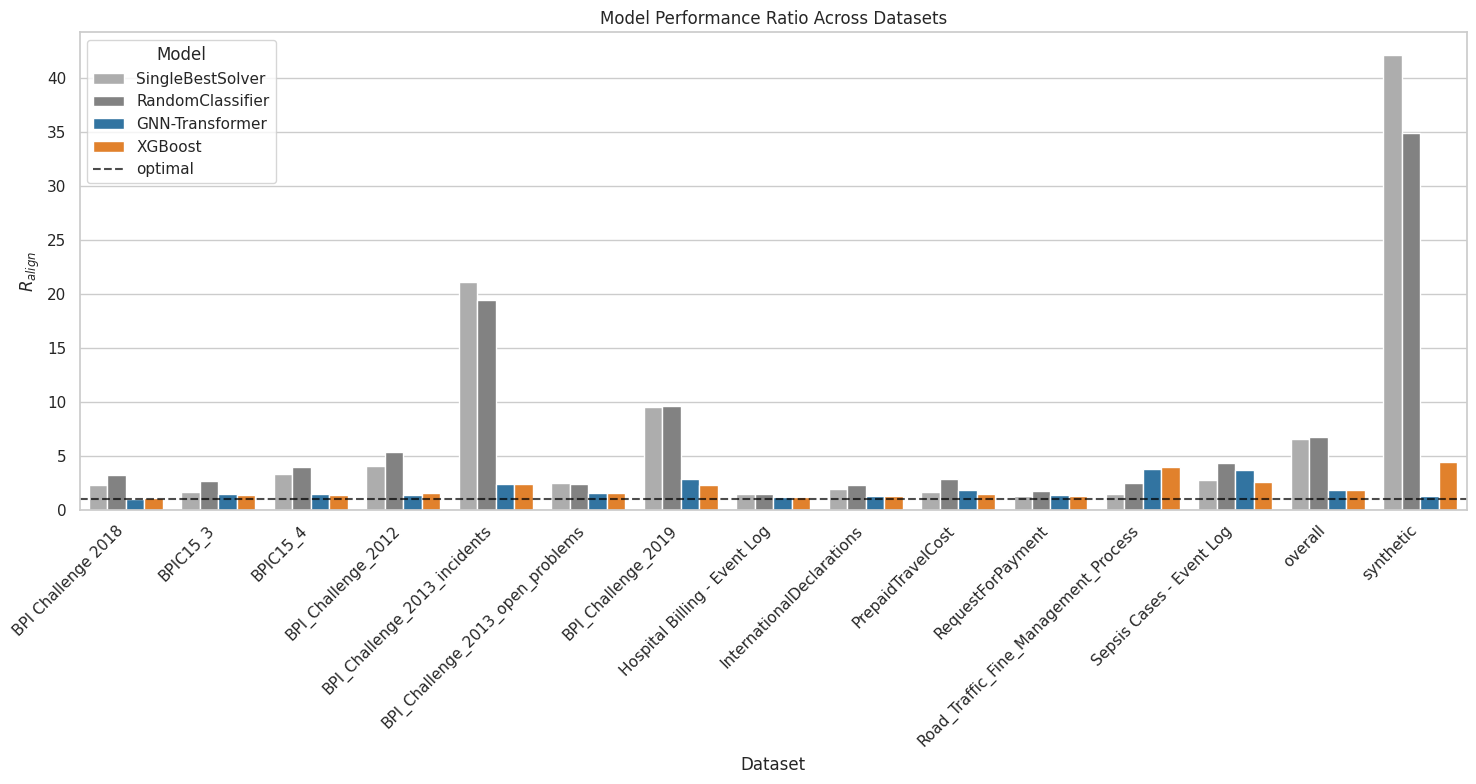

In [23]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=df,
    x="dataset",
    order=datasets,
    y="performance_ratio",
    hue="model",
    hue_order=models,
    palette=model_palette,
    errorbar=None  # important if values are single measurements
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
ax.axhline(
    y=1.0,                # or whatever "ideal" means
    linestyle="--",
    linewidth=1.5,
    color="black",
    alpha=0.7,
    label="optimal"
)

plt.ylabel("$R_{align}$")
plt.xlabel("Dataset")
plt.title("Model Performance Ratio Across Datasets")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1154363/827456979.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")


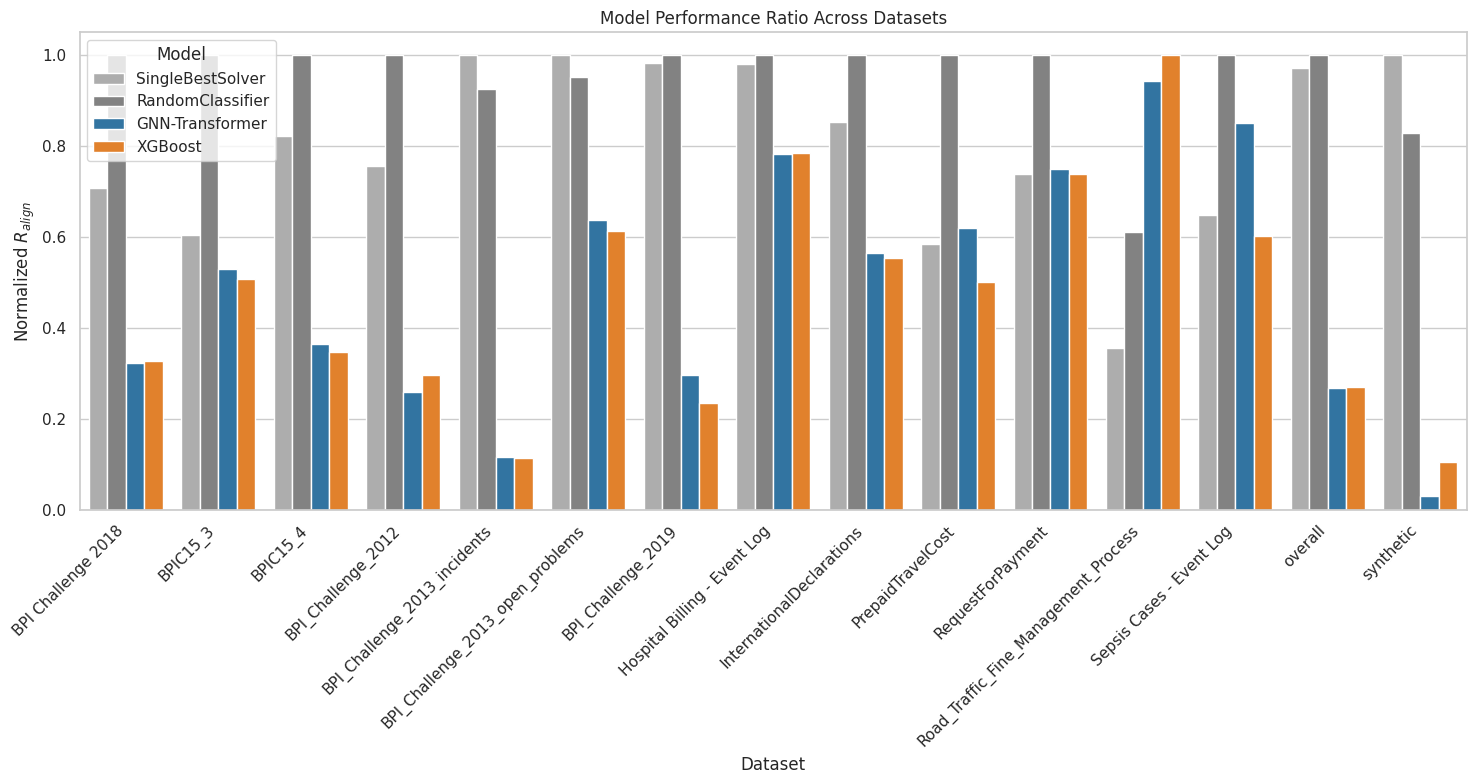

In [22]:
sns.set_theme(style="whitegrid")

plt.figure(figsize=(15, 8))
ax = sns.barplot(
    data=df,
    x="dataset",
    order=datasets,
    y="performance_ratio_norm",
    hue="model",
    hue_order=models,
    palette=model_palette,
    errorbar=None  # important if values are single measurements
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

plt.ylabel("Normalized $R_{{align}}$")
plt.xlabel("Dataset")
plt.title("Model Performance Ratio Across Datasets")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

[0, 10, 20]
(0.5257977700884275, 0.5257977700884275, 0.5257977700884275) SingleBestSolver
[0.80721311 0.73948718 0.68889858 0.64156627 0.26934985 0.30555556
 0.48562816 0.56183965 0.60390314 0.64739101 0.65337423 0.6031861
 0.49471459 0.57375971 0.16355472]
[0.1757377  0.08703297 0.09503051 0.17570281 0.16408669 0.02777778
 0.09796534 0.12802983 0.13516444 0.12107522 0.15541922 0.12527154
 0.11688312 0.10608852 0.0475065 ]
[0.00393443 0.02490842 0.03342052 0.01506024 0.0619195  0.04166667
 0.0279901  0.02548167 0.03505602 0.02371809 0.02607362 0.04127444
 0.03865902 0.0291705  0.03474356]
(0.40784313725490196, 0.40784313725490196, 0.40784313725490196) RandomClassifier
[0.54491803 0.50139194 0.48270851 0.47188755 0.27863777 0.27777778
 0.38034234 0.45059043 0.44380195 0.46080867 0.44274029 0.45401883
 0.39987919 0.42667895 0.22595131]
[0.26491803 0.17245421 0.16928219 0.19578313 0.14551084 0.08333333
 0.13413715 0.15102548 0.17997832 0.17280325 0.21932515 0.16292542
 0.1371187  0.156051

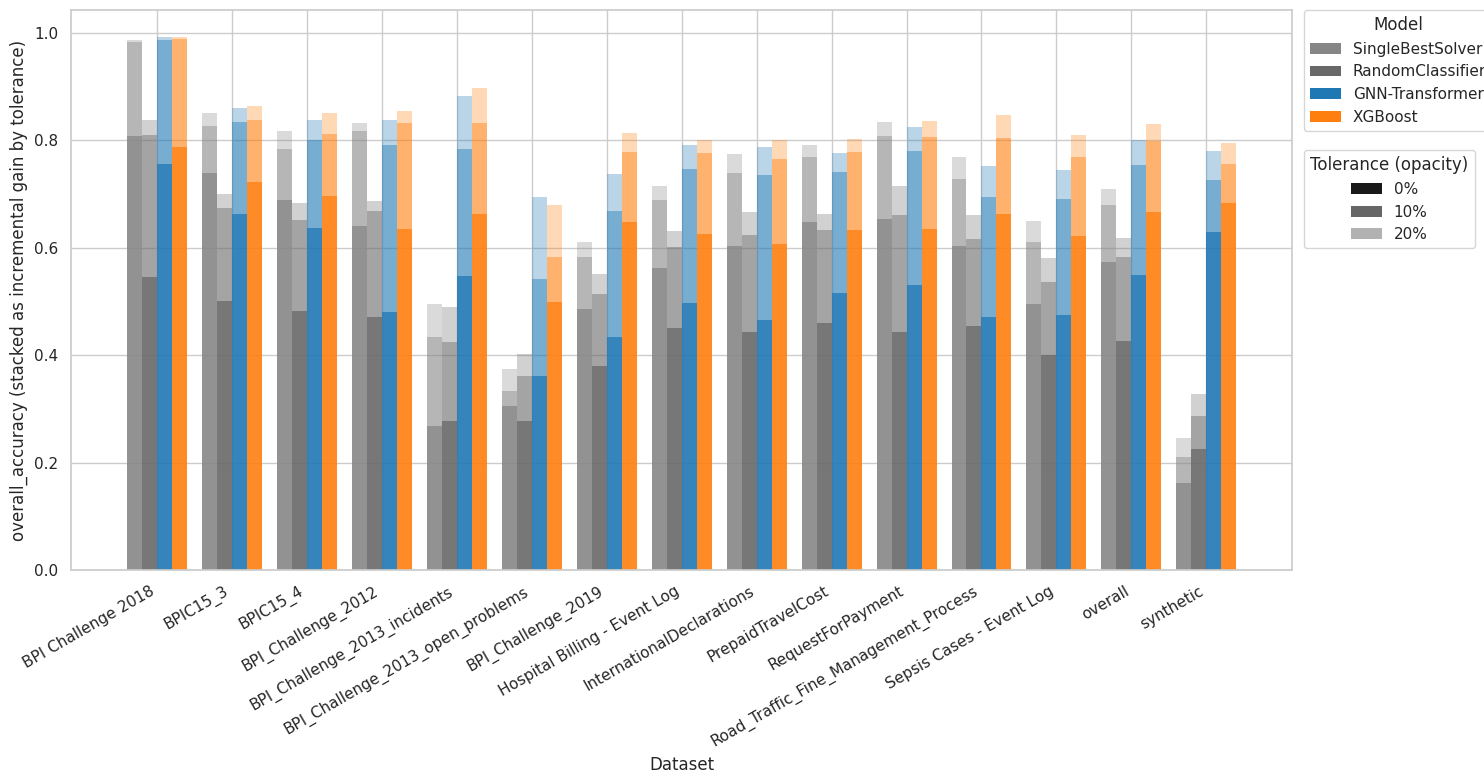

In [ ]:
import numpy as np

KEY = "overall_accuracy"

# 1) Build long-form dataframe: one row per (model, dataset, tolerance)
rows = []
for model, evaluated_data in res.items():
    for dataset_name, eval_result in evaluated_data.items():
        tol_metrics = eval_result.get("tolerance_metrics", {})
        for tol_key, tol_payload in tol_metrics.items():
            rows.append({
                "model": MODEL_RENAME.get(model, model),
                "dataset": DATASET_NAMES.get(dataset_name, dataset_name),
                "tolerance": tol_key,
                "tolerance_int": int(tol_key.rstrip("%")),
                KEY: float(tol_payload[KEY]),
            })

df = pd.DataFrame(rows)
if df.empty:
    raise ValueError("No macro_accuracy values found under tolerance_metrics.")

# 2) Sort tolerances and compute stackable deltas within each (model, dataset)
df = df.sort_values(["dataset", "model", "tolerance_int"])
df["prev_acc"] = df.groupby(["dataset", "model"])[KEY].shift(1).fillna(0.0)
df["delta_acc"] = df[KEY] - df["prev_acc"]

grayscale_models = set(GRAYSCALE_MODELS)  # if it’s a dict, we only care about keys

# split models
gray_models = [m for m in models if m in grayscale_models]
color_models = [m for m in models if m not in grayscale_models]

# generate palettes
color_palette = sns.color_palette("tab10", n_colors=len(color_models))
# gray_palette = sns.color_palette("Greys", n_colors=len(gray_models) + 6)[4:-2]
gray_palette = sns.color_palette("Greys", n_colors=len(gray_models) + 6)[4:-2]

# build explicit mapping
model_palette = {}

for m, c in zip(color_models, color_palette):
    model_palette[m] = c

for m, c in zip(gray_models, gray_palette):
    model_palette[m] = c

# If tolerance is monotonic, deltas should be >= 0. If not, you’ll see negative stacks.
# You can clamp negatives if you want, but that hides problems:
# df["delta_acc"] = df["delta_acc"].clip(lower=0.0)

# 3) Pivot deltas to wide: columns=tolerances, rows=(dataset, model)
wide = df.pivot_table(
    index=["dataset", "model"],
    columns="tolerance_int",
    values="delta_acc",
    aggfunc="first",
    fill_value=0.0
).sort_index()

# Ensure tolerances are in ascending order
tols = list(wide.columns)
print(tols)

# 4) Plot grouped + stacked bars
from matplotlib.patches import Patch

sns.set_theme(style="whitegrid")

x = np.arange(len(datasets))
n_models = len(models)
group_width = 0.8
bar_width = group_width / max(n_models, 1)

# Base colors per model (like "hue")
# model_colors = dict(zip(models, sns.color_palette(n_colors=len(models))))

# Alpha per tolerance (like "stack tone")
# You can flip this if you prefer higher tolerance = more opaque.
alphas = np.linspace(0.9, 0.3, num=len(tols))
tol_alpha = dict(zip(tols, alphas))

fig, ax = plt.subplots(figsize=(15, 8))

for mi, model in enumerate(models):
    bottoms = np.zeros(len(datasets), dtype=float)
    xpos = x - group_width/2 + (mi + 0.5) * bar_width

    base_color = model_palette[model]
    print(base_color, model)

    for tol in tols:
        heights = np.array(
            [wide.loc[(ds, model), tol] if (ds, model) in wide.index else 0.0 for ds in datasets],
            dtype=float
        )
        print(heights)

        ax.bar(
            xpos,
            heights,
            bottom=bottoms,
            width=bar_width,
            color=base_color,          # model color
            alpha=tol_alpha[tol],      # tolerance tone
            edgecolor="none"
        )
        bottoms += heights

# Axes cosmetics
ax.set_xticks(x)
ax.set_xticklabels(datasets, rotation=30, ha="right")
ax.set_ylabel(f"{KEY} (stacked as incremental gain by tolerance)")
ax.set_xlabel("Dataset")
# ax.set_title(f"{KEY} vs Tolerance, grouped by model")

# ---- Legends ----
# Legend 1: models
model_handles = [Patch(facecolor=model_palette[m], edgecolor="none", label=m) for m in models]
leg1 = ax.legend(
    handles=model_handles,
    title="Model",
    loc="upper left",
    bbox_to_anchor=(1.01, 1.0),
    borderaxespad=0.0
)
ax.add_artist(leg1)

# Legend 2: tolerances (alpha)
# Use a neutral facecolor so the alpha is readable regardless of model color
tol_handles = [
    Patch(facecolor="black", edgecolor="none", alpha=tol_alpha[t], label=f"{t}%")
    for t in tols
]
ax.legend(
    handles=tol_handles,
    title="Tolerance (opacity)",
    loc="upper left",
    bbox_to_anchor=(1.01, 0.75),
    borderaxespad=0.0
)

plt.tight_layout(w_pad=1.5)
plt.show()

In [15]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Callable, Iterable, Mapping, Sequence
import math
import re


@dataclass(frozen=True)
class MetricSpec:
    """One table row."""
    label_tex: str
    getter: Callable[[Mapping[str, Any]], Any]
    fmt: Callable[[Any], str]


def _escape_latex(text: str) -> str:
    # conservative LaTeX escaping for captions/labels/plain text cells
    repl = {
        "\\": r"\textbackslash{}",
        "&": r"\&",
        "%": r"\%",
        "$": r"\$",
        "#": r"\#",
        "_": r"\_",
        "{": r"\{",
        "}": r"\}",
        "~": r"\textasciitilde{}",
        "^": r"\textasciicircum{}",
    }
    return "".join(repl.get(c, c) for c in text)


def _is_number(x: Any) -> bool:
    return isinstance(x, (int, float)) and not isinstance(x, bool)


def _fmt_float(ndp: int = 3) -> Callable[[Any], str]:
    def f(x: Any) -> str:
        if x is None:
            return "-"
        if _is_number(x):
            if isinstance(x, float) and (math.isnan(x) or math.isinf(x)):
                return "-"
            return f"{float(x):.{ndp}f}"
        return "-"
    return f


def _fmt_ms(ndp: int = 3) -> Callable[[Any], str]:
    # input seconds -> milliseconds formatted
    def f(x: Any) -> str:
        if x is None or not _is_number(x):
            return "-"
        v = float(x) * 1000.0
        return f"{v:.{ndp}f}"
    return f


def _fmt_percent_from_unit(ndp: int = 2) -> Callable[[Any], str]:
    # input in [0,1] -> percent string
    def f(x: Any) -> str:
        if x is None or not _is_number(x):
            return "-"
        v = float(x) * 100.0
        return f"{v:.{ndp}f}\\%"
    return f


def _get_path(d: Mapping[str, Any], path: Sequence[str], default=None):
    cur: Any = d
    for k in path:
        if not isinstance(cur, Mapping) or k not in cur:
            return default
        cur = cur[k]
    return cur


def make_default_metric_specs(tolerances: Iterable[str] = ("0%", "10%", "20%")) -> list[MetricSpec]:
    """
    Produces a row-set similar to your example table.
    Adjust tolerances and/or add/remove specs as needed.
    """
    specs: list[MetricSpec] = [
        MetricSpec(
            label_tex=r"$R_{align}$",
            getter=lambda r: r.get("performance_ratio_alignment_only"),
            fmt=_fmt_float(3),
        ),
        MetricSpec(
            label_tex=r"$R_{align + pred}$",
            getter=lambda r: r.get("performance_ratio_with_prediction"),
            fmt=_fmt_float(3),
        ),
        MetricSpec(
            label_tex=r"Align Time (s)",
            getter=lambda r: r.get("mean_alignment_time_only"),
            fmt=_fmt_float(3),
        ),
        MetricSpec(
            label_tex=r"Pred + Align Time (s)",
            getter=lambda r: r.get("mean_alignment_time_with_prediction"),
            fmt=_fmt_float(3),
        ),
        MetricSpec(
            label_tex=r"Pred Time (ms)",
            getter=lambda r: r.get("mean_prediction_time"),  # optional if you have it
            fmt=_fmt_ms(3),
        ),
        MetricSpec(
            label_tex=r"Feature Extraction Time (ms)",
            getter=lambda r: r.get("mean_prediction_time"),  # optional if you have it
            fmt=_fmt_ms(3),
        ),
        MetricSpec(
            label_tex=r"$S_{worst}$",
            getter=lambda r: r.get("time_savings_vs_worst"),
            fmt=_fmt_percent_from_unit(2),
        ),
    ]

    for tol in tolerances:
        specs.extend([
            MetricSpec(
                label_tex=rf"Acc {tol}",
                getter=lambda r, tol=tol: _get_path(r, ("tolerance_metrics", tol, "overall_accuracy")),
                fmt=_fmt_float(3),
            ),
            MetricSpec(
                label_tex=rf"Macro {tol}",
                getter=lambda r, tol=tol: _get_path(r, ("tolerance_metrics", tol, "macro_accuracy")),
                fmt=_fmt_float(3),
            ),
        ])

    return specs


def iter_tex_tables(
    res: Mapping[str, Mapping[str, Mapping[str, Any]]],
    *,
    dataset_keys: Sequence[str] | None = None,
    include_overall: bool = False,
    overall_key: str = "overall",
    model_order: Sequence[str] | None = None,
    model_rename: Mapping[str, str] | None = None,
    metric_specs: Sequence[MetricSpec] | None = None,
    caption_fn: Callable[[str], str] | None = None,
    label_fn: Callable[[str], str] | None = None,
    table_position: str = "ht",
    float_fmt_fallback: Callable[[Any], str] | None = None,
) -> Iterable[tuple[str, str, str]]:
    """
    Generator yielding (dataset_key, tex_string, debug_info).

    res is assumed to be:
      res[model][dataset_key] -> dict with fields including:
        tolerance_metrics, mean_alignment_time_only, performance_ratio_with_prediction, ...

    Notes:
    - If dataset_keys is None, it will use the union of all dataset keys across models.
    - If include_overall is True, it will also generate a table for overall_key if present.
    - metric_specs controls rows; use make_default_metric_specs(...) or provide your own.
    """
    if model_rename is None:
        model_rename = {}
    if metric_specs is None:
        metric_specs = make_default_metric_specs()
    if float_fmt_fallback is None:
        float_fmt_fallback = _fmt_float(3)

    models = list(model_order) if model_order is not None else sorted(res.keys())

    # compute dataset keys
    if dataset_keys is None:
        key_set = set()
        for m in models:
            if m in res:
                key_set.update(res[m].keys())
        keys = sorted(key_set)
    else:
        keys = list(dataset_keys)

    if include_overall and overall_key not in keys:
        keys.append(overall_key)

    def default_caption(ds: str) -> str:
        # customize as you like
        if ds == overall_key:
            return r"\textbf{Overall} Model Comparison"
        return rf"\textbf{{{_escape_latex(ds)}}} Model Comparison"

    def default_label(ds: str) -> str:
        safe = re.sub(r"[^a-zA-Z0-9]+", "_", ds).strip("_").lower()
        return f"tab:{safe}_model_comparison"

    caption_fn = caption_fn or default_caption
    label_fn = label_fn or default_label

    for ds in keys:
        # Collect per-model result dict (may be missing)
        per_model: dict[str, Mapping[str, Any] | None] = {
            m: res.get(m, {}).get(ds) for m in models
        }

        # Build header
        display_models = [model_rename.get(m, m) for m in models]
        cols_spec = "l" + ("r" * len(models))

        lines: list[str] = []
        lines.append(rf"\begin{{table}}[{table_position}]")
        lines.append(r"\centering")
        lines.append(rf"\caption{{{caption_fn(ds)}}}")
        lines.append(rf"\label{{{_escape_latex(label_fn(ds))}}}")
        lines.append(rf"\begin{{tabular}}{{{cols_spec}}}")
        lines.append(r"\hline")
        header = " & ".join([r"\textbf{Metric}"] + [rf"\textbf{{{_escape_latex(name)}}}" for name in display_models])
        lines.append(header + r" \\")
        lines.append(r"\hline")

        # Rows
        missing_notes = []
        for spec in metric_specs:
            row = [spec.label_tex]
            for m in models:
                rdict = per_model[m]
                if rdict is None:
                    row.append("-")
                    missing_notes.append(f"missing {ds} for model={m}")
                    continue
                try:
                    val = spec.getter(rdict)
                except Exception as e:
                    val = None
                    missing_notes.append(f"getter error on {ds}/{m}/{spec.label_tex}: {e!r}")

                try:
                    cell = spec.fmt(val)
                except Exception as e:
                    cell = float_fmt_fallback(val)
                    missing_notes.append(f"fmt error on {ds}/{m}/{spec.label_tex}: {e!r}")

                row.append(cell if cell is not None else "-")

            lines.append(" & ".join(row) + r" \\")

        lines.append(r"\hline")
        lines.append(r"\end{tabular}")
        lines.append(r"\end{table}")

        tex = "\n".join(lines)
        debug = "\n".join(missing_notes)
        yield ds, tex, debug

In [ ]:
specs = make_default_metric_specs(tolerances=("0%", "10%", "20%"))

for ds, tex, debug in iter_tex_tables(
    res,
    dataset_keys=None,                 # or a list in the order you want
    include_overall=True,
    overall_key="overall",
    model_order=None,                  # or your explicit order
    model_rename={
        "XGBoostClassifier": "XGBoost",
        "SpectralModel": "GNN-Transformer",
    },
    metric_specs=specs,
):
    print(f"=== {ds} ===")
    print(tex)
    if debug:
        print("DEBUG:\n", debug)

=== 12683249 ===
\begin{table}[ht]
\centering
\caption{\textbf{12683249} Model Comparison}
\label{tab:12683249\_model\_comparison}
\begin{tabular}{lrrrr}
\hline
\textbf{Metric} & \textbf{RandomClassifier} & \textbf{SingleBestSolver} & \textbf{GNN-Transformer} & \textbf{XGBoost} \\
\hline
$R_{align}$ & 2.453 & 1.428 & 5.367 & 3.991 \\
$R_{align + pred}$ & 2.453 & 1.428 & 5.414 & 4.012 \\
Align Time (s) & 0.109 & 0.063 & 0.239 & 0.177 \\
Pred + Align Time (s) & 0.109 & 0.063 & 0.241 & 0.178 \\
Pred Time (ms) & 0.028 & 0.000 & 2.081 & 0.911 \\
Feature Extraction Time (ms) & 0.028 & 0.000 & 2.081 & 0.911 \\
$S_{worst}$ & 97.83\% & 99.36\% & 93.47\% & 95.53\% \\
Acc 0% & 0.454 & 0.603 & 0.412 & 0.664 \\
Macro 0% & 0.259 & 0.250 & 0.405 & 0.440 \\
Acc 10% & 0.617 & 0.728 & 0.666 & 0.805 \\
Macro 10% & 0.478 & 0.500 & 0.706 & 0.677 \\
Acc 20% & 0.662 & 0.770 & 0.713 & 0.847 \\
Macro 20% & 0.481 & 0.533 & 0.759 & 0.688 \\
\hline
\end{tabular}
\end{table}
=== 3301445f-95e8-4ff0-98a4-901f1f20497

In [ ]:
from typing import Mapping, Sequence, Literal, Any, Iterable

def _tol_to_int(t: str) -> int:
    m = re.match(r"^\s*(\d+)\s*%\s*$", str(t))
    if not m:
        raise ValueError(f"Bad tolerance key: {t!r}")
    return int(m.group(1))


def _fmt_int(x: Any) -> str:
    if x is None:
        return "-"
    if isinstance(x, bool):
        return "-"
    if isinstance(x, (int,)):
        return str(x)
    if isinstance(x, float) and math.isfinite(x) and abs(x - round(x)) < 1e-9:
        return str(int(round(x)))
    return "-"  # keep strict


def _fmt_percent_from_unit(x: Any, ndp: int = 2) -> str:
    if x is None or not isinstance(x, (int, float)) or isinstance(x, bool):
        return "-"
    x = float(x)
    if not math.isfinite(x):
        return "-"
    return f"{x * 100.0:.{ndp}f}"


def _fmt_percent_from_percent(x: Any, ndp: int = 2) -> str:
    # if metric is already in percent space [0..100]
    if x is None or not isinstance(x, (int, float)) or isinstance(x, bool):
        return "-"
    x = float(x)
    if not math.isfinite(x):
        return "-"
    return f"{x:.{ndp}f}"


def _get_path(d: Mapping[str, Any], path: Sequence[str], default=None):
    cur: Any = d
    for k in path:
        if not isinstance(cur, Mapping) or k not in cur:
            return default
        cur = cur[k]
    return cur

def iter_tex_detail_tables(
    res: Mapping[str, Mapping[str, Mapping[str, Any]]],
    *,
    model: str,
    dataset: str,
    tolerances: Sequence[str] = ("0%", "10%", "20%"),
    detail: Literal["combination", "heuristic"] = "combination",
    metric_key: str = "recall",
    metric_is: Literal["unit", "percent"] = "unit",
    sort_by: Literal["support", "correct", "metric", "name"] = "support",
    sort_desc: bool = True,
    top_k: int | None = None,
    min_support: int | None = None,
    caption_prefix: str | None = None,
    label_prefix: str = "tab",
    table_position: str = "ht",
    model_display: str | None = None,
    dataset_display: str | None = None,
    tolerance_in_caption: bool = True,
) -> Iterable[tuple[str, str]]:
    """
    Generates LaTeX tables for per-combination or per-heuristic metrics at given tolerances.

    Yields: (tolerance_key, tex_table_string)

    Expects your JSON shape (as shown):
      res[model][dataset]["tolerance_metrics"][tol]["combination_metrics"][name] -> {support, correct_predictions, recall, ...}
      res[model][dataset]["tolerance_metrics"][tol]["per_heuristic_metrics"][name] -> {total_optimal_samples, true_positives, recall, f1_score, accuracy, ...}

    For combination_metrics:
      - support key: "support"
      - correct key: "correct_predictions"
      - metric key: metric_key (e.g. "recall", "f1_score", ...)

    For per_heuristic_metrics:
      - support key defaults to "total_optimal_samples" if present else ("true_positives"+"false_negatives")
      - correct key defaults to "true_positives"
      - metric key: metric_key (e.g. "recall", "f1_score", "accuracy", ...)

    metric_is:
      - "unit": metric values are in [0,1] (converted to %)
      - "percent": metric values already in [0,100]
    """
    model_display = model_display or model
    dataset_display = dataset_display or dataset

    if model not in res or dataset not in res[model]:
        raise KeyError(f"Missing res[{model!r}][{dataset!r}]")

    root = res[model][dataset]
    tol_metrics = root.get("tolerance_metrics", {})
    if not isinstance(tol_metrics, Mapping):
        raise ValueError("tolerance_metrics missing or not a dict")

    # nice ordering if user passes unsorted tolerances
    tolerances = sorted(tolerances, key=_tol_to_int)

    # Choose section + default header nouns
    if detail == "combination":
        section_key = "combination_metrics"
        first_col_name = "Combination"
        # keys inside each entry
        support_get: Callable[[Mapping[str, Any]], Any] = lambda d: d.get("support")
        correct_get: Callable[[Mapping[str, Any]], Any] = lambda d: d.get("correct_predictions")
    else:
        section_key = "per_heuristic_metrics"
        first_col_name = "Heuristic"

        def support_get(d: Mapping[str, Any]) -> Any:
            if "total_optimal_samples" in d:
                return d.get("total_optimal_samples")
            # fallback: tp + fn if present
            tp = d.get("true_positives")
            fn = d.get("false_negatives")
            if isinstance(tp, (int, float)) and isinstance(fn, (int, float)):
                return int(tp + fn)
            return d.get("support")  # last resort

        correct_get = lambda d: d.get("true_positives")

    # metric formatter
    if metric_is == "unit":
        metric_fmt = lambda v: _fmt_percent_from_unit(v, ndp=2)
    else:
        metric_fmt = lambda v: _fmt_percent_from_percent(v, ndp=2)

    # caption/label defaults
    def default_caption(tol: str) -> str:
        # Example wants: "Per-Combination Performance \textbf{GNN-Transformer} (10\% Tolerance)"
        prefix = caption_prefix or f"Per-{first_col_name} Performance"
        tol_part = f" ({_escape_latex(tol)} Tolerance)" if tolerance_in_caption else ""
        return rf"{_escape_latex(prefix)} \textbf{{{_escape_latex(model_display)}}}{tol_part}"

    def default_label(tol: str) -> str:
        # Example: tab:per_combination_10_gnn
        tol_int = _tol_to_int(tol)
        md = re.sub(r"[^a-zA-Z0-9]+", "_", model_display).strip("_").lower()
        return f"{label_prefix}:per_{detail}_{tol_int}_{md}"

    for tol in tolerances:
        tol_block = tol_metrics.get(tol)
        if not isinstance(tol_block, Mapping):
            continue

        section = tol_block.get(section_key, {})
        if not isinstance(section, Mapping) or not section:
            continue

        # collect rows
        rows = []
        for name, entry in section.items():
            if not isinstance(entry, Mapping):
                continue
            support = support_get(entry)
            correct = correct_get(entry)
            metric_val = entry.get(metric_key)

            # min_support filter
            if min_support is not None:
                try:
                    s_int = int(support) if support is not None else 0
                except Exception:
                    s_int = 0
                if s_int < min_support:
                    continue

            rows.append({
                "name": str(name),
                "support": support,
                "correct": correct,
                "metric": metric_val,
            })

        # sorting
        if sort_by == "support":
            key_fn = lambda r: (int(r["support"]) if str(r["support"]).isdigit() else -1)
        elif sort_by == "correct":
            key_fn = lambda r: (int(r["correct"]) if str(r["correct"]).isdigit() else -1)
        elif sort_by == "metric":
            def key_fn(r):
                v = r["metric"]
                return float(v) if isinstance(v, (int, float)) and math.isfinite(float(v)) else float("-inf")
        else:
            key_fn = lambda r: r["name"].lower()

        rows.sort(key=key_fn, reverse=sort_desc)

        if top_k is not None:
            rows = rows[:top_k]

        # build LaTeX
        lines = []
        lines.append(rf"\begin{{table}}[{table_position}]")
        lines.append(r"\centering")
        lines.append(rf"\caption{{{default_caption(tol)}}}")
        lines.append(rf"\label{{{_escape_latex(default_label(tol))}}}")
        lines.append(r"\begin{tabular}{l r r r}")
        lines.append(r"\hline")
        metric_title = f"{_escape_latex(metric_key.replace('_', ' ').title())} (\\%)"
        lines.append(rf"\textbf{{{first_col_name}}} & \textbf{{Support}} & \textbf{{Correct}} & \textbf{{{metric_title}}} \\")
        lines.append(r"\hline")

        for r in rows:
            name_tex = _escape_latex(r["name"]).replace(r"\+", "+")  # keep '+' readable if present
            lines.append(
                f"{name_tex} & {_fmt_int(r['support'])} & {_fmt_int(r['correct'])} & {metric_fmt(r['metric'])} \\\\"
            )

        lines.append(r"\hline")
        lines.append(r"\end{tabular}")
        lines.append(r"\end{table}")

        yield tol, "\n".join(lines)

In [ ]:
for tol, tex in iter_tex_detail_tables(
    res,
    model="XGBoostClassifier",
    dataset="overall",                 # or your dataset id/name
    tolerances=("0%", "10%", "20%"),
    detail="combination",
    metric_key="f1_score",               # or "f1_score", "precision", ...
    metric_is="unit",                  # your JSON recall is in [0,1]
    sort_by="support",
    sort_desc=True,
):
    print(tex)
    print()

NameError: name 'iter_tex_detail_tables' is not defined